# Recipe Recommendation System

### Project Phases:

**1. Problem Definition:** Recommendation system – the user answers questions about their preferences (meal type, cooking method, ingredients, complexity, etc.), and the system finds the best matching recipes from a database of 62,000+ recipes.

**2. Data Ingestion:** Loading a CSV file containing recipe titles, categories, descriptions, ingredients, preparation steps, and statistics.

**3. Exploratory Data Analysis (EDA):** Statistical overview and visualization of distributions.

**4. Feature Engineering & Preprocessing:**
* Extracting features from text fields (ingredients, directions): meal type, cooking method, protein type, cuisine, sweet/spicy, etc.
* Encoding: Converting text categories to numbers (OneHotEncoder).
* Scaling: Normalizing numeric values (StandardScaler).
* Pipeline: Automated processing chain.

**5. Modeling:**
* KMeans clustering to group recipes by similar characteristics.
* Classification (LogisticRegression, RandomForest, KNN) to predict cluster membership.
* NearestNeighbors to find the closest recipes to user preferences.

**6. Evaluation:**
* Silhouette Score for cluster quality.
* Accuracy and Cross-Validation for classification models.
* Interactive console-based recommendation system.

In [1]:
import os
import re
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, silhouette_score

DATA_DIR = os.path.join(os.getcwd(), "data")
LOCAL_PATH = os.path.join(DATA_DIR, "recipes.csv")

df = pd.read_csv(LOCAL_PATH)
print(f"Data loaded: {LOCAL_PATH}")
print(f"Shape: {df.shape}")
df.head()

Data loaded: /Users/stilianvelichkov/Development/IISI_Project/recipe-recommendation-project/data/recipes.csv
Shape: (62126, 8)


,recipe_title,category,subcategory,description,ingredients,directions,num_ingredients,num_steps
0,Air Fryer Potato Slices with Dipping Sauce,Air Fryer Recipes,Air Fryer Recipes,"These air fryer potato slices, served with a b...","[""3/4 cup ketchup"", ""1/2 cup beer"", ""1 tablesp...","[""Combine ketchup, beer, Worcestershire sauce,...",9,5
1,Gochujang Pork Belly Bites,Air Fryer Recipes,Air Fryer Recipes,These gochujang pork belly bites are sweet and...,"[""1 pound pork belly"", ""1/4 cup gochujang"", ""2...","[""Preheat an air fryer to 400 degrees F (200 d...",5,4
2,3-Ingredient Air Fryer Everything Bagel Chicke...,Air Fryer Recipes,Air Fryer Recipes,These 3-ingredient air fryer everything bagel ...,"[""1 \u00bc pounds chicken tenders"", ""1 tablesp...","[""Gather all ingredients. Preheat an air fryer...",3,4
3,Air Fryer Everything Bagel Chicken Cutlets,Air Fryer Recipes,Air Fryer Recipes,These air fryer everything bagel chicken cutle...,"[""4 chicken cutlets (about 1 pound total)"", ""s...","[""Preheat an air fryer to 400 degrees F (200 d...",9,9
4,Air Fryer Honey Sriracha Salmon Bites,Air Fryer Recipes,Air Fryer Recipes,These air fryer honey Sriracha salmon bites ar...,"[""1 tablespoon soy sauce"", ""1 tablespoon honey...","[""Preheat an air fryer to 400 degrees F (200 d...",5,5


**What happens in this block:**
* Importing core libraries: `numpy`, `pandas`, `matplotlib`, `seaborn`, and `scikit-learn`.
* Loading the CSV file with 62,000+ recipes and their attributes.
* Each row represents a specific recipe with 8 attributes: title, category, subcategory, description, ingredients, directions, number of ingredients, and number of steps.

In [2]:
display(df.shape)
display(df.columns.tolist())
display(df.head(3))
display(df.describe(include="all").T)

print("\nMissing values:")
display(df.isnull().sum())

(62126, 8)

['recipe_title',
 'category',
 'subcategory',
 'description',
 'ingredients',
 'directions',
 'num_ingredients',
 'num_steps']

,recipe_title,category,subcategory,description,ingredients,directions,num_ingredients,num_steps
0,Air Fryer Potato Slices with Dipping Sauce,Air Fryer Recipes,Air Fryer Recipes,"These air fryer potato slices, served with a b...","[""3/4 cup ketchup"", ""1/2 cup beer"", ""1 tablesp...","[""Combine ketchup, beer, Worcestershire sauce,...",9,5
1,Gochujang Pork Belly Bites,Air Fryer Recipes,Air Fryer Recipes,These gochujang pork belly bites are sweet and...,"[""1 pound pork belly"", ""1/4 cup gochujang"", ""2...","[""Preheat an air fryer to 400 degrees F (200 d...",5,4
2,3-Ingredient Air Fryer Everything Bagel Chicke...,Air Fryer Recipes,Air Fryer Recipes,These 3-ingredient air fryer everything bagel ...,"[""1 \u00bc pounds chicken tenders"", ""1 tablesp...","[""Gather all ingredients. Preheat an air fryer...",3,4


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
recipe_title,62126,24971,Blackened Chicken,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,62126,267,Main Dishes,3387,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subcategory,62126,1032,Meatloaf,320,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,62126,25015,Blackened chicken is quick and easy to make at...,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ingredients,62126,24971,"[""cooking spray""]",72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
directions,62126,25014,"[""Gather all ingredients. Preheat the oven to ...",26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_ingredients,62126.0,NaN,NaN,NaN,9.017448,3.830323,1.0,6.0,9.0,11.0,35.0
num_steps,62126.0,NaN,NaN,NaN,4.661865,2.310253,1.0,3.0,4.0,6.0,25.0



Missing values:


recipe_title       0
category           0
subcategory        0
description        0
ingredients        0
directions         0
num_ingredients    0
num_steps          0
dtype: int64

**Slot 2: Exploratory Data Analysis**

* Scale check (`shape` & `columns`): Understanding how many recipes we have and what features are described.
* Statistical profile (`describe`): Reviewing averages for ingredient and step counts.
* Missing data analysis: Checking for empty cells in the data.

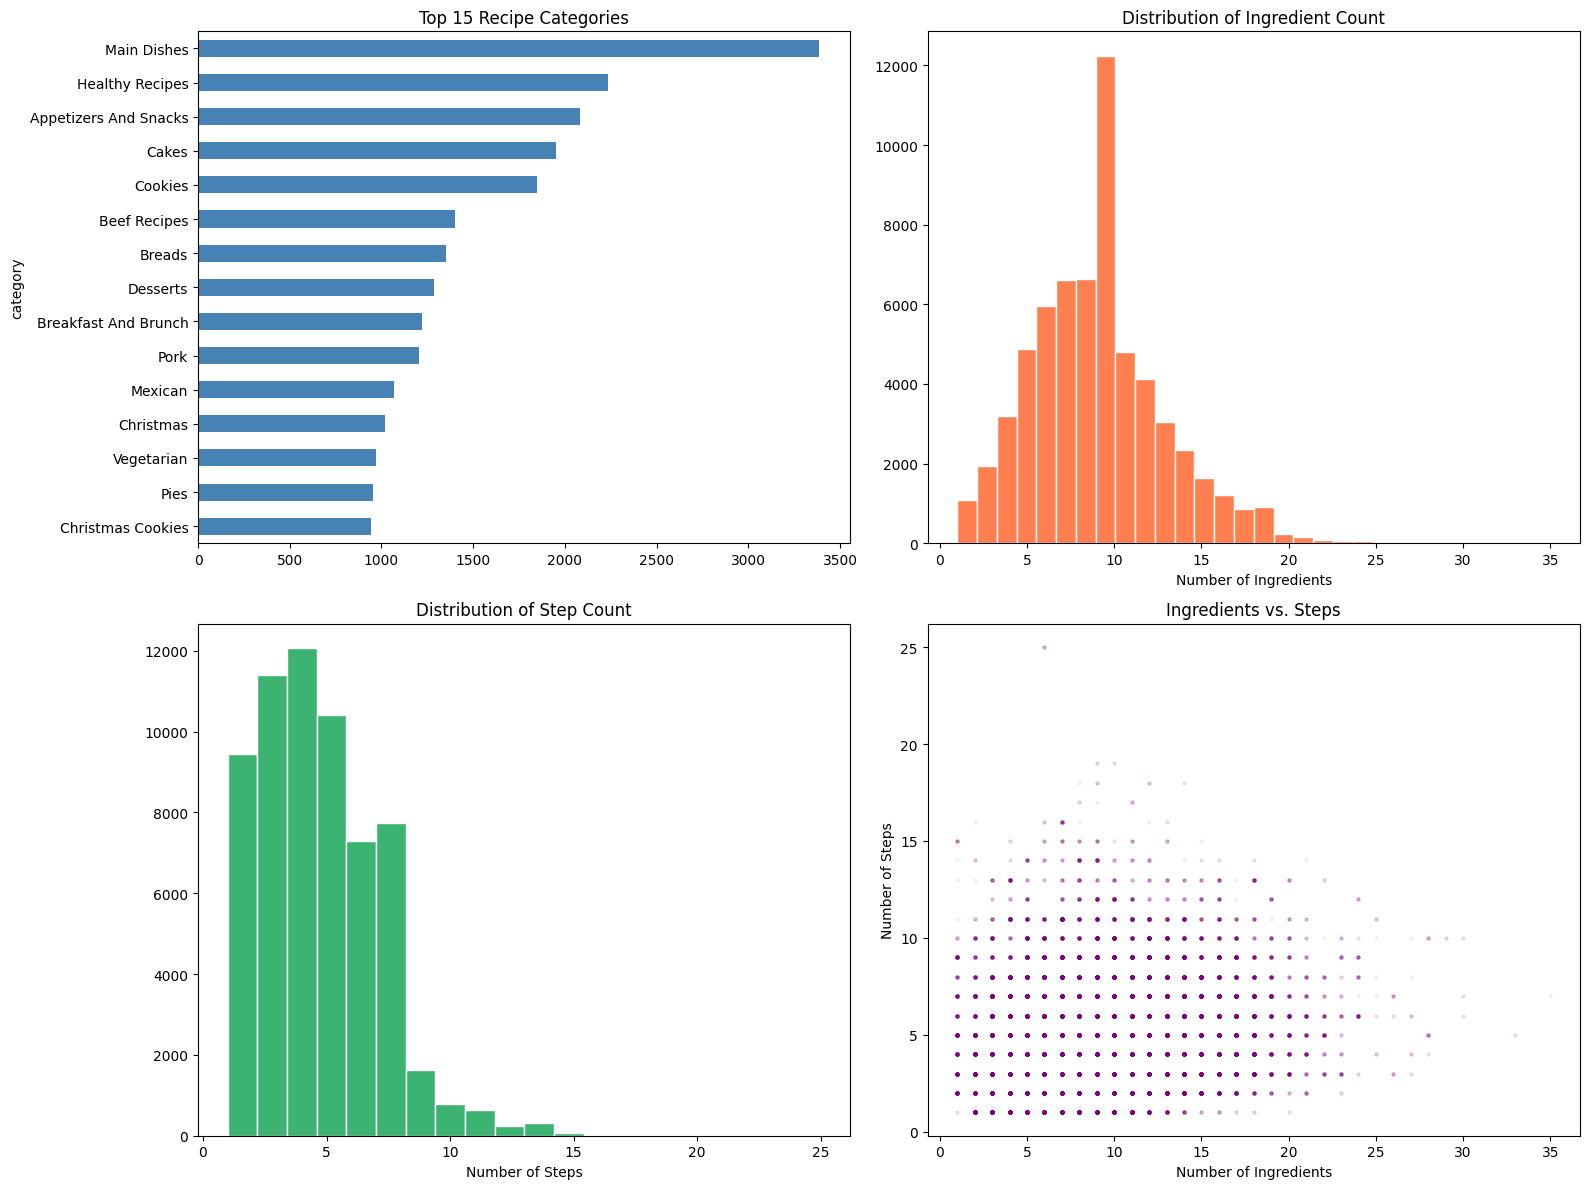

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

df["category"].value_counts().head(15).plot.barh(ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Top 15 Recipe Categories")
axes[0, 0].invert_yaxis()

axes[0, 1].hist(df["num_ingredients"], bins=30, color="coral", edgecolor="white")
axes[0, 1].set_title("Distribution of Ingredient Count")
axes[0, 1].set_xlabel("Number of Ingredients")

axes[1, 0].hist(df["num_steps"], bins=20, color="mediumseagreen", edgecolor="white")
axes[1, 0].set_title("Distribution of Step Count")
axes[1, 0].set_xlabel("Number of Steps")

axes[1, 1].scatter(df["num_ingredients"], df["num_steps"], alpha=0.05, s=5, color="purple")
axes[1, 1].set_title("Ingredients vs. Steps")
axes[1, 1].set_xlabel("Number of Ingredients")
axes[1, 1].set_ylabel("Number of Steps")

plt.tight_layout()
plt.show()

**Slot 3: Visualizations**

* The horizontal bar chart shows the most popular recipe categories.
* Histograms reveal the distribution of complexity (ingredient and step counts).
* The scatter plot shows the relationship between ingredients and steps – more complex recipes typically have more of both.

In [4]:
def safe_lower(text):
    return str(text).lower() if pd.notna(text) else ""


def extract_meal_type(row):
    cat = safe_lower(row["category"])
    sub = safe_lower(row["subcategory"])
    combined = cat + " " + sub

    drink_kw = ["cocktail", "margarita", "eggnog", "lemonade", "jell-o shot", "bloody mary", "mojito"]
    dessert_kw = ["cake", "cookie", "dessert", "pie", "brownie", "fudge", "ice cream", "cheesecake",
                  "cupcake", "pastri", "mousse", "frosting", "icing", "cobbler", "crisp", "crumble",
                  "fruitcake", "blondie", "biscotti", "macaroon", "gingerbread", "gingersnap",
                  "pavlova", "whoopie", "fondant", "divinity", "angel food", "flan",
                  "creme brulee", "lemon bar", "chocolate chip", "oatmeal cookie",
                  "peanut butter cookie", "chess pie", "key lime", "mincemeat",
                  "cherry pie", "apple pie", "blueberry pie", "pecan pie", "chocolate fudge"]
    bread_kw = ["bread", "muffin", "bagel", "flatbread", "cornbread", "doughnut", "donut",
                "popover", "yorkshire", "english muffin", "pizza dough", "cracker",
                "hushpuppy", "biscuit", "kolache", "danish"]
    breakfast_kw = ["breakfast", "brunch", "pancake", "french toast", "omelet", "frittata",
                    "oatmeal", "waffle", "overnight oat", "grit", "strata", "blintze",
                    "cinnamon roll", "coffee cake"]
    appetizer_kw = ["appetizer", "snack", "deviled egg", "popcorn", "jalapeno popper",
                    "cheese ball", "hummus", "artichoke dip", "ceviche", "bruschetta",
                    "antipasti", "guacamole", "empanada", "egg roll", "nacho",
                    "buffalo chicken dip", "lettuce wrap", "falafel", "pate",
                    "cheese fondue", "buffalo chicken wing", "energy ball"]
    soup_kw = ["soup", "chili", "chowder", "gumbo", "stew", "minestrone", "gazpacho",
               "borscht", "etouffee", "jambalaya"]
    salad_kw = ["salad", "coleslaw", "slaw"]
    side_kw = ["fries", "mashed potato", "yam", "baked bean", "polenta", "pickle",
               "cranberry sauce", "gravy", "pesto", "garlic bread", "jam", "jelly",
               "applesauce", "brine", "canning", "preserv", "jerky"]

    for kw in drink_kw:
        if kw in combined:
            return "drink"
    for kw in dessert_kw:
        if kw in combined:
            return "dessert"
    for kw in bread_kw:
        if kw in combined:
            return "bread"
    for kw in breakfast_kw:
        if kw in combined:
            return "breakfast"
    for kw in appetizer_kw:
        if kw in combined:
            return "appetizer"
    for kw in soup_kw:
        if kw in combined:
            return "soup"
    for kw in salad_kw:
        if kw in combined:
            return "salad"
    for kw in side_kw:
        if kw in combined:
            return "side_dish"
    return "main_course"


def extract_cooking_method(directions_str):
    text = safe_lower(directions_str)
    if "air fr" in text or "air-fr" in text:
        return "air_fryer"
    if "instant pot" in text or "pressure cook" in text:
        return "instant_pot"
    if "slow cook" in text or "crock" in text or "crockpot" in text:
        return "slow_cooker"
    if "grill" in text or "barbecue" in text or "bbq" in text:
        return "grill"
    if "preheat" in text and ("oven" in text or "bake" in text or "roast" in text):
        return "oven"
    if "deep fr" in text or "deep-fr" in text:
        return "deep_fry"
    if "fry" in text or "saute" in text or "sauté" in text or "skillet" in text or "pan" in text or "wok" in text:
        return "stovetop"
    if "boil" in text or "simmer" in text or "steam" in text:
        return "stovetop"
    if "microwave" in text:
        return "microwave"
    if "no-bake" in text or "no bake" in text or "no cook" in text or "refrigerat" in text:
        return "no_cook"
    return "other"


def extract_protein(ingredients_str):
    text = safe_lower(ingredients_str)
    if any(kw in text for kw in ["chicken", "turkey", "poultry"]):
        return "poultry"
    if any(kw in text for kw in ["beef", "steak", "ground beef", "sirloin", "chuck", "brisket"]):
        return "beef"
    if any(kw in text for kw in ["pork", "bacon", "ham", "sausage", "prosciutto"]):
        return "pork"
    if any(kw in text for kw in ["lamb", "veal"]):
        return "lamb"
    if any(kw in text for kw in ["salmon", "shrimp", "tuna", "cod", "tilapia", "crab",
                                  "lobster", "scallop", "clam", "mussel", "anchov",
                                  "fish", "seafood", "calamari", "oyster"]):
        return "seafood"
    return "vegetarian"


def extract_cuisine(category):
    cat = safe_lower(category)
    if any(kw in cat for kw in ["italian", "lasagna", "pasta", "fettuccin", "linguine",
                                 "ziti", "gnocchi", "manicotti", "carbonara", "primavera",
                                 "pizza", "calzone", "bruschetta", "antipasti",
                                 "chicken parmesan", "eggplant parmesan", "chicken marsala",
                                 "chicken piccata", "polenta", "minestrone"]):
        return "italian"
    if any(kw in cat for kw in ["mexican", "enchilada", "burrito", "fajita", "nacho",
                                 "taco", "chilaquile", "chiles relleno", "ceviche",
                                 "guacamole", "empanada"]):
        return "mexican"
    if any(kw in cat for kw in ["chinese", "fried rice", "egg roll", "pancit"]):
        return "asian"
    if any(kw in cat for kw in ["indian", "diwali"]):
        return "asian"
    if any(kw in cat for kw in ["korean", "bulgogi", "kalbi"]):
        return "asian"
    if any(kw in cat for kw in ["pad thai", "teriyaki", "hawaiian", "lunar new year"]):
        return "asian"
    if any(kw in cat for kw in ["comfort food", "mardi gras", "cajun", "southern"]):
        return "comfort"
    if any(kw in cat for kw in ["mediterranean"]):
        return "mediterranean"
    if any(kw in cat for kw in ["french onion", "crepe", "french toast"]):
        return "french"
    return "other"


def extract_is_sweet(row):
    ingr = safe_lower(row["ingredients"])
    cat = safe_lower(row["category"])
    sweet_cat = ["cake", "cookie", "dessert", "pie", "brownie", "fudge", "ice cream",
                 "cheesecake", "cupcake", "frosting", "cobbler", "chocolate"]
    if any(kw in cat for kw in sweet_cat):
        return 1
    sweet_ingr = ["sugar", "vanilla extract", "chocolate", "cocoa", "maple syrup",
                  "brown sugar", "powdered sugar", "confectioner", "molasses",
                  "caramel", "marshmallow"]
    count = sum(1 for kw in sweet_ingr if kw in ingr)
    return 1 if count >= 2 else 0


def extract_is_spicy(ingredients_str):
    text = safe_lower(ingredients_str)
    spicy_kw = ["cayenne", "chili powder", "jalapeno", "sriracha", "hot sauce",
                "chipotle", "habanero", "red pepper flake", "crushed red pepper",
                "gochujang", "tabasco", "serrano", "thai chili"]
    count = sum(1 for kw in spicy_kw if kw in text)
    return 1 if count >= 1 else 0


def extract_has_dairy(ingredients_str):
    text = safe_lower(ingredients_str)
    dairy_kw = ["cheese", "milk", "cream", "butter", "yogurt", "sour cream",
                "cream cheese", "whipping cream", "half-and-half", "ricotta",
                "mozzarella", "cheddar", "parmesan"]
    count = sum(1 for kw in dairy_kw if kw in text)
    return 1 if count >= 1 else 0


def compute_complexity(row):
    ni = row["num_ingredients"]
    ns = row["num_steps"]
    if ni <= 5 and ns <= 3:
        return 1
    elif ni <= 10 and ns <= 6:
        return 2
    else:
        return 3


print("Feature extraction functions defined.")
print("Starting Feature Engineering...")

df["meal_type"] = df.apply(extract_meal_type, axis=1)
df["cooking_method"] = df["directions"].apply(extract_cooking_method)
df["protein_type"] = df["ingredients"].apply(extract_protein)
df["cuisine"] = df["category"].apply(extract_cuisine)
df["is_sweet"] = df.apply(extract_is_sweet, axis=1)
df["is_spicy"] = df["ingredients"].apply(extract_is_spicy)
df["has_dairy"] = df["ingredients"].apply(extract_has_dairy)
df["complexity"] = df.apply(compute_complexity, axis=1)

df_fe = df.copy()

print(f"\nFeature Engineering complete. New columns: {df_fe.shape[1] - 8}")
print(f"Shape: {df_fe.shape}")

print("\n--- meal_type distribution ---")
display(df_fe["meal_type"].value_counts())
print("\n--- cooking_method distribution ---")
display(df_fe["cooking_method"].value_counts())
print("\n--- protein_type distribution ---")
display(df_fe["protein_type"].value_counts())
print("\n--- cuisine distribution ---")
display(df_fe["cuisine"].value_counts())
print("\n--- complexity distribution ---")
display(df_fe["complexity"].value_counts())

Feature extraction functions defined.
Starting Feature Engineering...

Feature Engineering complete. New columns: 8
Shape: (62126, 16)

--- meal_type distribution ---


meal_type
main_course    26731
dessert        14756
appetizer       4700
bread           4324
breakfast       3253
soup            2838
salad           2662
side_dish       1688
drink           1174
Name: count, dtype: int64


--- cooking_method distribution ---


cooking_method
oven           27982
stovetop       18214
other           5422
grill           2787
no_cook         2391
slow_cooker     2066
air_fryer       1241
instant_pot      800
deep_fry         657
microwave        566
Name: count, dtype: int64


--- protein_type distribution ---


protein_type
vegetarian    38204
poultry        8593
beef           6463
pork           5991
seafood        2458
lamb            417
Name: count, dtype: int64


--- cuisine distribution ---


cuisine
other            55386
italian           2408
mexican           1619
asian             1397
comfort           1145
french             116
mediterranean       55
Name: count, dtype: int64


--- complexity distribution ---


complexity
2    30831
3    26123
1     5172
Name: count, dtype: int64

**Slot 4: Feature Engineering**

* **meal_type**: Extracted from category – classifies the recipe as main course, dessert, appetizer, soup, salad, drink, etc.
* **cooking_method**: Extracted from directions – determines cooking method (oven, grill, air fryer, slow cooker, etc.).
* **protein_type**: Extracted from ingredients – identifies the main protein (chicken, beef, pork, seafood, vegetarian).
* **cuisine**: Extracted from category – identifies cuisine type (Italian, Mexican, Asian, etc.).
* **is_sweet / is_spicy / has_dairy**: Binary features extracted from ingredients.
* **complexity**: Derived from ingredient and step counts (1=easy, 2=medium, 3=complex).

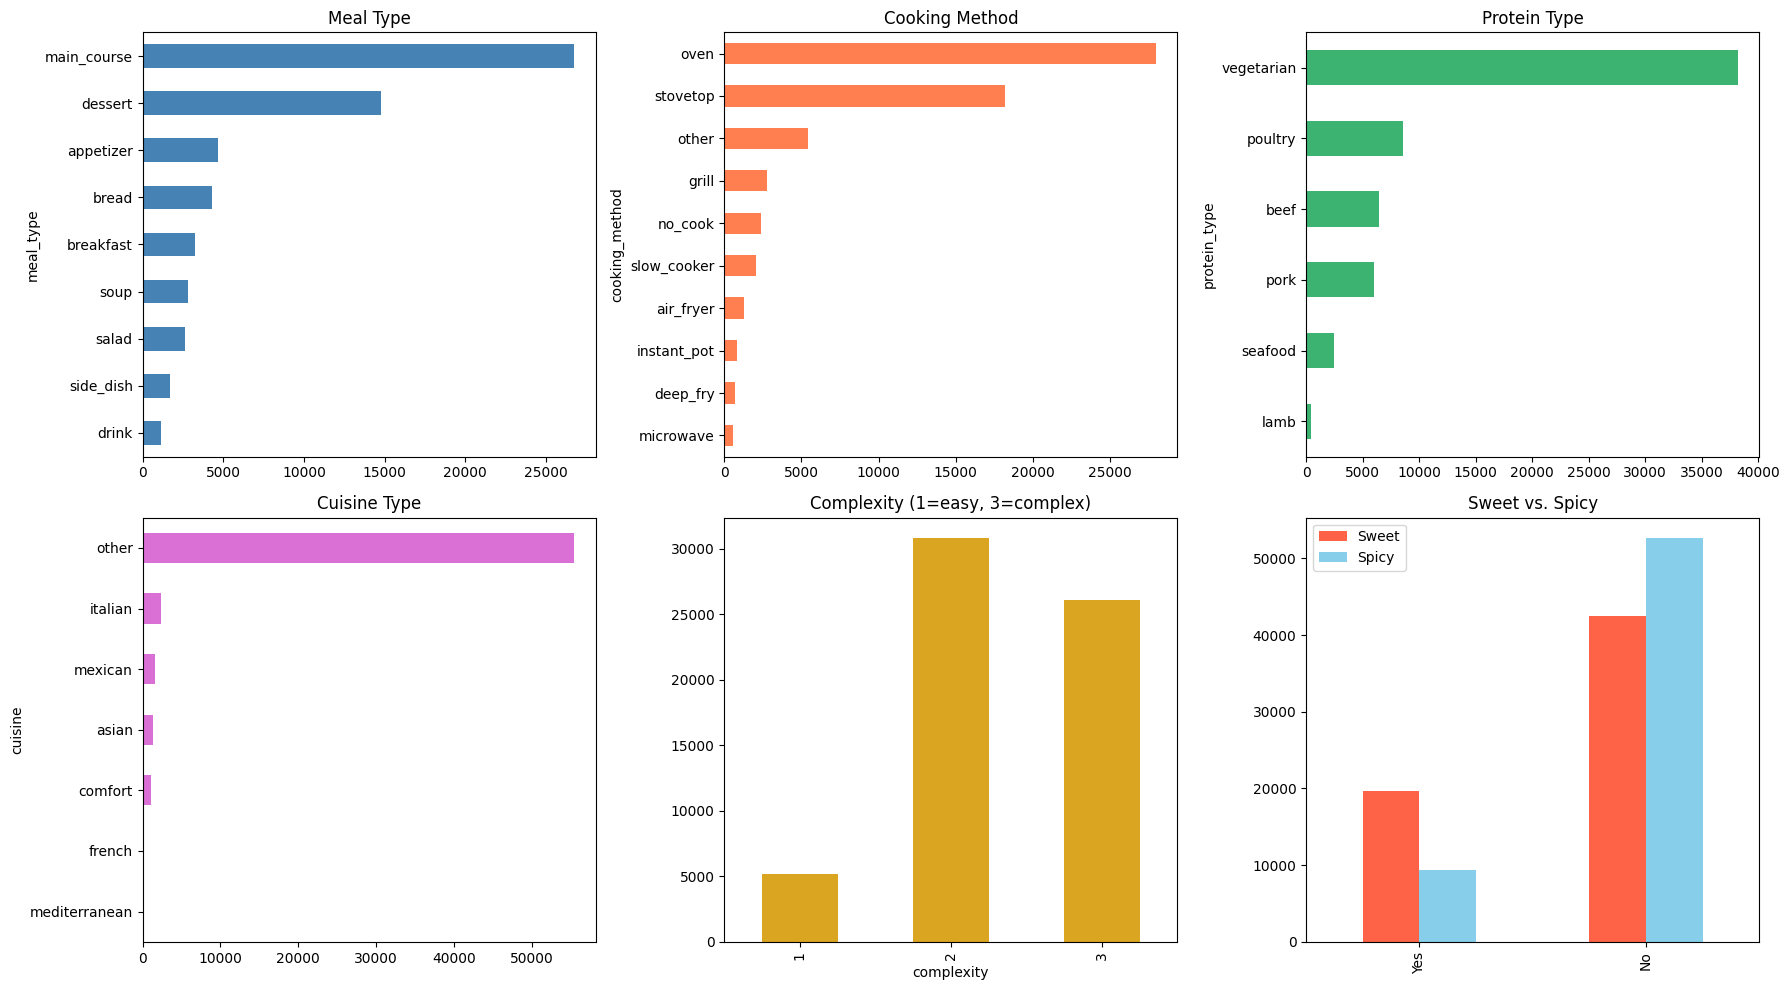

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

df_fe["meal_type"].value_counts().plot.barh(ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Meal Type")
axes[0, 0].invert_yaxis()

df_fe["cooking_method"].value_counts().plot.barh(ax=axes[0, 1], color="coral")
axes[0, 1].set_title("Cooking Method")
axes[0, 1].invert_yaxis()

df_fe["protein_type"].value_counts().plot.barh(ax=axes[0, 2], color="mediumseagreen")
axes[0, 2].set_title("Protein Type")
axes[0, 2].invert_yaxis()

df_fe["cuisine"].value_counts().plot.barh(ax=axes[1, 0], color="orchid")
axes[1, 0].set_title("Cuisine Type")
axes[1, 0].invert_yaxis()

df_fe["complexity"].value_counts().sort_index().plot.bar(ax=axes[1, 1], color="goldenrod")
axes[1, 1].set_title("Complexity (1=easy, 3=complex)")

sweet_spicy = pd.DataFrame({
    "Sweet": [df_fe["is_sweet"].sum(), len(df_fe) - df_fe["is_sweet"].sum()],
    "Spicy": [df_fe["is_spicy"].sum(), len(df_fe) - df_fe["is_spicy"].sum()],
}, index=["Yes", "No"])
sweet_spicy.plot.bar(ax=axes[1, 2], color=["tomato", "skyblue"])
axes[1, 2].set_title("Sweet vs. Spicy")

plt.tight_layout()
plt.show()

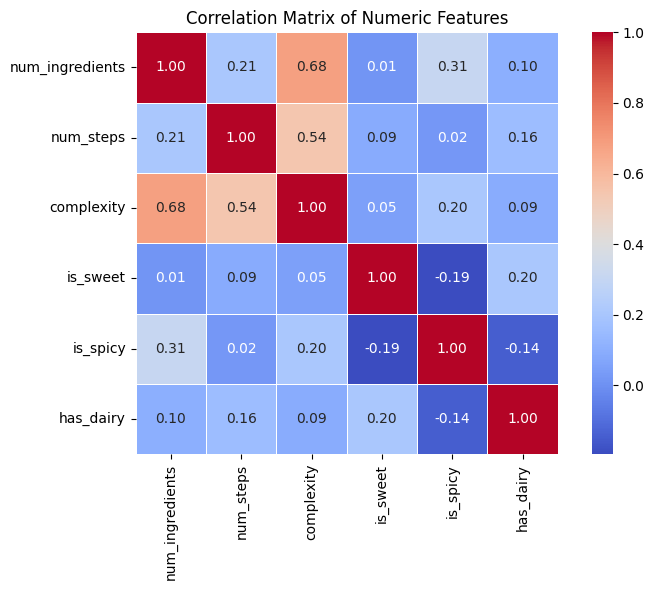

In [6]:
numeric_cols = ["num_ingredients", "num_steps", "complexity", "is_sweet", "is_spicy", "has_dairy"]
corr = df_fe[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True, linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

**Slot 5: Extracted Feature Visualizations**

* The horizontal bar charts show the distribution of extracted features.
* The correlation matrix reveals relationships between numeric features – for example, desserts tend to be sweet and have more ingredients.

In [7]:
FEATURE_COLS_CAT = ["meal_type", "cooking_method", "protein_type", "cuisine"]
FEATURE_COLS_NUM = ["num_ingredients", "num_steps", "complexity",
                    "is_sweet", "is_spicy", "has_dairy"]

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler()),
])
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, FEATURE_COLS_NUM),
        ("cat", categorical_transformer, FEATURE_COLS_CAT),
    ],
    remainder="drop"
)

X = df_fe[FEATURE_COLS_CAT + FEATURE_COLS_NUM]
X_transformed = preprocessor.fit_transform(X)

print(f"Original shape: {X.shape}")
print(f"Transformed shape: {X_transformed.shape}")
print(f"(Numeric: {len(FEATURE_COLS_NUM)}, Categorical -> OneHot: {X_transformed.shape[1] - len(FEATURE_COLS_NUM)})")

Original shape: (62126, 10)
Transformed shape: (62126, 38)
(Numeric: 6, Categorical -> OneHot: 32)


**Slot 6: Preprocessing Pipeline**

* `Pipeline` is an automated chain of steps, analogous to the one in the car recommendation project.
* `ColumnTransformer` applies different processing for numeric and categorical features:
  - **Numeric**: `StandardScaler` – normalizes values.
  - **Categorical**: `OneHotEncoder` – converts text categories to numbers.
* This ensures all features have equal weight during modeling.

k=3: Silhouette Score = 0.2010
k=4: Silhouette Score = 0.2107
k=5: Silhouette Score = 0.1947
k=6: Silhouette Score = 0.2001
k=7: Silhouette Score = 0.2034
k=8: Silhouette Score = 0.2093
k=9: Silhouette Score = 0.2095
k=10: Silhouette Score = 0.2047
k=11: Silhouette Score = 0.2171

Best k = 11 (Silhouette = 0.2171)


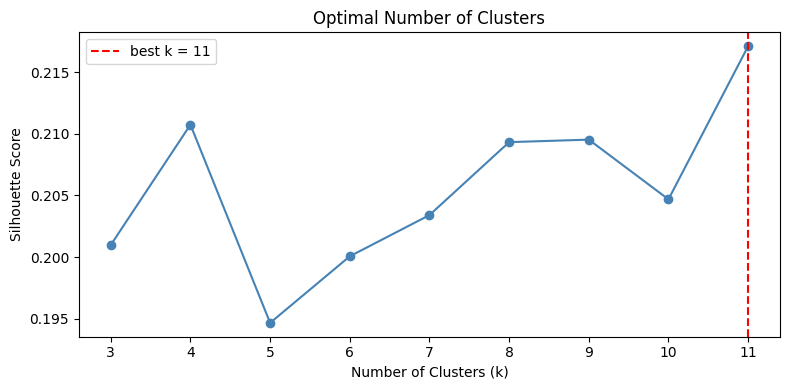

In [8]:
silhouette_scores = []
K_RANGE = range(3, 12)

sample_idx = np.random.RandomState(42).choice(X_transformed.shape[0], size=min(10000, X_transformed.shape[0]), replace=False)
X_sample = X_transformed[sample_idx]

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    silhouette_scores.append(score)
    print(f"k={k}: Silhouette Score = {score:.4f}")

best_k = list(K_RANGE)[np.argmax(silhouette_scores)]
print(f"\nBest k = {best_k} (Silhouette = {max(silhouette_scores):.4f})")

plt.figure(figsize=(8, 4))
plt.plot(list(K_RANGE), silhouette_scores, "o-", color="steelblue")
plt.axvline(best_k, color="red", linestyle="--", label=f"best k = {best_k}")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Optimal Number of Clusters")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_fe["cluster"] = kmeans.fit_predict(X_transformed)

print("Cluster distribution:")
display(df_fe["cluster"].value_counts().sort_index())

cluster_profiles = df_fe.groupby("cluster").agg({
    "meal_type": lambda x: x.mode().iloc[0],
    "cooking_method": lambda x: x.mode().iloc[0],
    "protein_type": lambda x: x.mode().iloc[0],
    "cuisine": lambda x: x.mode().iloc[0],
    "num_ingredients": "mean",
    "num_steps": "mean",
    "is_sweet": "mean",
    "is_spicy": "mean",
    "has_dairy": "mean",
    "recipe_title": "count",
}).rename(columns={"recipe_title": "count"})

print("\nCluster profiles:")
display(cluster_profiles.round(2))

for c in range(best_k):
    sample = df_fe[df_fe["cluster"] == c][["recipe_title", "meal_type", "cooking_method", "protein_type"]].sample(
        min(3, len(df_fe[df_fe["cluster"] == c])), random_state=42)
    print(f"\nCluster {c} examples:")
    display(sample)

Cluster distribution:


cluster
0     3832
1     3208
2     4759
3     8728
4     9809
5     7292
6     2882
7     7838
8     6420
9     4076
10    3282
Name: count, dtype: int64


Cluster profiles:


,meal_type,cooking_method,protein_type,cuisine,num_ingredients,num_steps,is_sweet,is_spicy,has_dairy,count
cluster,,,,,,,,,,
0,dessert,oven,vegetarian,other,8.63,4.53,1.00,0.00,0.00,3832
1,main_course,stovetop,vegetarian,other,13.79,4.93,0.15,1.00,0.00,3208
2,main_course,oven,vegetarian,other,8.24,8.75,0.04,0.01,0.61,4759
3,main_course,stovetop,vegetarian,other,6.91,3.66,0.00,0.00,0.00,8728
4,main_course,oven,vegetarian,other,7.51,4.02,0.00,0.00,1.00,9809
5,main_course,stovetop,poultry,other,13.26,4.67,0.00,0.00,0.61,7292
6,main_course,oven,poultry,other,14.14,5.83,0.07,1.00,1.00,2882
7,dessert,oven,vegetarian,other,7.18,3.92,1.00,0.00,1.00,7838
8,dessert,oven,vegetarian,other,11.46,6.42,1.00,0.00,0.99,6420



Cluster 0 examples:


...

,recipe_title,meal_type,cooking_method,protein_type
3764,Egg-Free Brownies,dessert,oven,vegetarian
10872,Chocolate Surprise Cupcakes,dessert,oven,vegetarian
57308,All American Apple Pie,dessert,oven,vegetarian



Cluster 9 examples:


,recipe_title,meal_type,cooking_method,protein_type
29919,Homemade Adobo All-Purpose Seasoning,main_course,other,vegetarian
33818,Buffalo and Ranch Pumpkin Seeds,main_course,oven,vegetarian
8034,Air Fryer Turkey Breakfast Sausage Links,breakfast,air_fryer,poultry



Cluster 10 examples:


,recipe_title,meal_type,cooking_method,protein_type
33442,Shrimp Gumbo,soup,stovetop,poultry
27885,Classic Cauliflower au Gratin,main_course,oven,vegetarian
45636,Grilled Pineapple Lime Chicken Thighs,main_course,grill,poultry


**Slot 7: KMeans Clustering**

* We use **KMeans** to automatically group recipes by similar characteristics.
* **Silhouette Score** measures cluster quality – how well the groups are separated.
* For efficiency, the Silhouette Score is computed on a sample of 10,000 recipes, while the final KMeans is trained on all data.
* Each cluster represents a recipe "profile": quick appetizers, complex desserts, spicy main courses, etc.
* These clusters serve as the target variable for classification models.

In [10]:
TARGET = "cluster"
y = df_fe[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
}

results = []
trained_models = {}
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)
    acc = accuracy_score(y_val, pred)
    cv = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
    results.append({"Model": name, "Val Accuracy": round(acc, 4),
                    "CV Mean": round(cv.mean(), 4), "CV Std": round(cv.std(), 4)})
    trained_models[name] = pipe
    print(f"{name}: Val Accuracy={acc:.4f}, CV={cv.mean():.4f} ± {cv.std():.4f}")

results_df = pd.DataFrame(results)
display(results_df)

LogisticRegression: Val Accuracy=0.9977, CV=0.9976 ± 0.0012
RandomForest: Val Accuracy=0.9990, CV=0.9982 ± 0.0003
KNN: Val Accuracy=0.9939, CV=0.9937 ± 0.0008


,Model,Val Accuracy,CV Mean,CV Std
0,LogisticRegression,0.9977,0.9976,0.0012
1,RandomForest,0.9990,0.9982,0.0003
2,KNN,0.9939,0.9937,0.0008


**Slot 8: Multiple Classification Models**

* We train 3 models: Logistic Regression, Random Forest, and KNN.
* Each model learns to predict a recipe's cluster based on its features.
* **Validation Accuracy**: Accuracy on unseen data.
* **Cross-Validation**: 5-fold cross-validation for result stability.
* These models will be used to classify user preferences into a cluster.

In [11]:
best_model_name = results_df.loc[results_df["CV Mean"].idxmax(), "Model"]
best_pipe = trained_models[best_model_name]
print(f"Best model: {best_model_name}")

best_pipe.fit(X, y)

nn_model = NearestNeighbors(n_neighbors=30, metric="euclidean")
nn_model.fit(X_transformed)

print(f"NearestNeighbors trained on {X_transformed.shape[0]} recipes")
print(f"Classifier ({best_model_name}) trained on full data")
print("\nSystem ready for interactive recommendations!")

Best model: RandomForest
NearestNeighbors trained on 62126 recipes
Classifier (RandomForest) trained on full data

System ready for interactive recommendations!


**Slot 9: Final Setup**

* We select the best classifier by CV Accuracy.
* We train it on the full dataset.
* We train a `NearestNeighbors` model for finding the closest recipes.
* The combination of both approaches:
  1. The classifier determines which cluster the preferences belong to.
  2. NearestNeighbors finds the specific recipes closest to the given criteria.

In [12]:
Q_MEAL_TYPE = {
    "text": "What type of meal are you looking for?",
    "options": [
        ("1", "Main course (lunch/dinner)", {"meal_type": "main_course"}),
        ("2", "Dessert / Sweet treat", {"meal_type": "dessert", "is_sweet": 1}),
        ("3", "Appetizer / Snack", {"meal_type": "appetizer"}),
        ("4", "Breakfast / Brunch", {"meal_type": "breakfast"}),
        ("5", "Soup / Stew", {"meal_type": "soup"}),
        ("6", "Salad", {"meal_type": "salad"}),
        ("7", "Bread / Baked goods", {"meal_type": "bread"}),
        ("8", "Drink / Cocktail", {"meal_type": "drink"}),
        ("9", "Side dish", {"meal_type": "side_dish"}),
    ],
}

Q_COOKING_SAVORY = {
    "text": "How would you like the dish to be prepared?",
    "options": [
        ("1", "Oven (baking, roasting)", {"cooking_method": "oven"}),
        ("2", "Stovetop (frying, sauteing)", {"cooking_method": "stovetop"}),
        ("3", "Grill / BBQ", {"cooking_method": "grill"}),
        ("4", "Air fryer", {"cooking_method": "air_fryer"}),
        ("5", "Slow cooker / Crockpot", {"cooking_method": "slow_cooker"}),
        ("6", "Instant Pot (pressure cooker)", {"cooking_method": "instant_pot"}),
        ("7", "No cooking needed (cold, raw)", {"cooking_method": "no_cook"}),
        ("8", "No preference", {"cooking_method": "oven"}),
    ],
}

Q_COOKING_SWEET = {
    "text": "How would you like it to be prepared?",
    "options": [
        ("1", "Oven (baking)", {"cooking_method": "oven"}),
        ("2", "Stovetop (melting, boiling)", {"cooking_method": "stovetop"}),
        ("3", "No cooking needed (fridge, no-bake)", {"cooking_method": "no_cook"}),
        ("4", "No preference", {"cooking_method": "oven"}),
    ],
}

Q_PROTEIN = {
    "text": "What protein do you prefer?",
    "options": [
        ("1", "Chicken / Turkey", {"protein_type": "poultry"}),
        ("2", "Beef", {"protein_type": "beef"}),
        ("3", "Pork", {"protein_type": "pork"}),
        ("4", "Lamb", {"protein_type": "lamb"}),
        ("5", "Fish / Seafood", {"protein_type": "seafood"}),
        ("6", "Vegetarian (no meat)", {"protein_type": "vegetarian"}),
        ("7", "No preference", {"protein_type": "poultry", "_protein_no_pref": True}),
    ],
}

Q_CUISINE = {
    "text": "Do you prefer a specific cuisine?",
    "options": [
        ("1", "Italian (pasta, pizza, risotto)", {"cuisine": "italian"}),
        ("2", "Mexican (tacos, burritos, enchiladas)", {"cuisine": "mexican"}),
        ("3", "Asian (Chinese, Indian, Korean, Thai, Japanese)", {"cuisine": "asian"}),
        ("4", "Mediterranean (Greek, Turkish, Lebanese)", {"cuisine": "mediterranean"}),
        ("5", "French", {"cuisine": "french"}),
        ("6", "Southern / Cajun / Comfort food", {"cuisine": "comfort"}),
        ("7", "No preference", {"cuisine": "other"}),
    ],
}

Q_COMPLEXITY = {
    "text": "How complex should the recipe be?",
    "options": [
        ("1", "Quick & easy (up to 5 ingredients, up to 3 steps)", {"complexity": 1, "num_ingredients": 4, "num_steps": 2}),
        ("2", "Moderate (6-10 ingredients, 4-6 steps)", {"complexity": 2, "num_ingredients": 8, "num_steps": 5}),
        ("3", "Complex / Gourmet (many ingredients and steps)", {"complexity": 3, "num_ingredients": 14, "num_steps": 9}),
    ],
}

Q_SWEET_SAVORY = {
    "text": "Do you prefer sweet or savory?",
    "options": [
        ("1", "Sweet (desserts, pastries)", {"is_sweet": 1}),
        ("2", "Savory", {"is_sweet": 0}),
        ("3", "No preference", {"is_sweet": 0}),
    ],
}

Q_SPICY = {
    "text": "Do you like spicy food?",
    "options": [
        ("1", "Yes, I love spicy food!", {"is_spicy": 1}),
        ("2", "No, I prefer mild flavors", {"is_spicy": 0}),
        ("3", "No preference", {"is_spicy": 0}),
    ],
}

Q_DAIRY = {
    "text": "Any preference for dairy?",
    "options": [
        ("1", "Yes, I love cheese, cream, and butter", {"has_dairy": 1}),
        ("2", "Prefer dairy-free", {"has_dairy": 0}),
        ("3", "No preference", {"has_dairy": 1}),
    ],
}

Q_DRINK_FLAVOR = {
    "text": "What kind of drink are you in the mood for?",
    "options": [
        ("1", "Sweet (smoothies, milkshakes, sweet cocktails)", {"is_sweet": 1, "has_dairy": 1}),
        ("2", "Fruity (lemonade, punch, fruit cocktails)", {"is_sweet": 1, "has_dairy": 0}),
        ("3", "Strong / Savory (classic cocktails, bloody mary)", {"is_sweet": 0, "has_dairy": 0}),
        ("4", "Creamy (eggnog, hot chocolate, cream-based)", {"is_sweet": 1, "has_dairy": 1}),
        ("5", "No preference", {"is_sweet": 0, "has_dairy": 0}),
    ],
}


def get_questions(meal_type):
    if meal_type == "dessert":
        return [Q_COOKING_SWEET, Q_COMPLEXITY, Q_DAIRY]
    if meal_type == "drink":
        return [Q_DRINK_FLAVOR, Q_COMPLEXITY]
    if meal_type == "bread":
        return [Q_COMPLEXITY, Q_SWEET_SAVORY, Q_DAIRY]
    if meal_type == "salad":
        return [Q_PROTEIN, Q_CUISINE, Q_COMPLEXITY, Q_DAIRY]
    if meal_type == "breakfast":
        return [Q_COOKING_SAVORY, Q_PROTEIN, Q_COMPLEXITY, Q_SWEET_SAVORY, Q_DAIRY]
    return [Q_COOKING_SAVORY, Q_PROTEIN, Q_CUISINE, Q_COMPLEXITY, Q_SPICY, Q_DAIRY]


print("Adaptive question system defined.")

Adaptive question system defined.


In [16]:
MEAL_DEFAULTS = {
    "dessert":     {"protein_type": "vegetarian", "cuisine": "other", "is_sweet": 1, "is_spicy": 0},
    "drink":       {"protein_type": "vegetarian", "cuisine": "other", "is_spicy": 0, "cooking_method": "other"},
    "bread":       {"protein_type": "vegetarian", "cuisine": "other", "is_spicy": 0},
    "breakfast":   {"cuisine": "other"},
    "salad":       {"cooking_method": "other", "is_spicy": 0, "is_sweet": 0},
    "side_dish":   {},
    "soup":        {},
    "appetizer":   {},
    "main_course": {},
}


def build_user_profile(answers):
    profile = {
        "meal_type": "main_course",
        "cooking_method": "oven",
        "protein_type": "poultry",
        "cuisine": "other",
        "num_ingredients": 8,
        "num_steps": 5,
        "complexity": 2,
        "is_sweet": 0,
        "is_spicy": 0,
        "has_dairy": 1,
    }
    meal = answers.get("meal_type", "main_course")
    profile.update(MEAL_DEFAULTS.get(meal, {}))
    for key, val in answers.items():
        profile[key] = val
    return profile


def recommend_recipes(profile, top_n=3):
    user_df = pd.DataFrame([profile])
    user_features = user_df[FEATURE_COLS_CAT + FEATURE_COLS_NUM]

    predicted_cluster = best_pipe.predict(user_features)[0]

    user_transformed = preprocessor.transform(user_features)
    search_n = min(top_n * 100, len(df_fe))
    distances, indices = nn_model.kneighbors(user_transformed, n_neighbors=search_n)

    candidates = df_fe.iloc[indices[0]].copy()
    candidates["distance"] = distances[0]
    candidates = candidates.drop_duplicates(subset=["recipe_title"], keep="first")

    meal_filter = candidates[candidates["meal_type"] == profile["meal_type"]]

    has_protein_pref = not profile.get("_protein_no_pref", False)
    if has_protein_pref:
        protein_filter = meal_filter[meal_filter["protein_type"] == profile["protein_type"]]
    else:
        protein_filter = pd.DataFrame()

    if len(protein_filter) >= top_n:
        pool = protein_filter
    elif len(meal_filter) >= top_n:
        pool = meal_filter
    else:
        pool = candidates

    cluster_matches = pool[pool["cluster"] == predicted_cluster]
    if len(cluster_matches) >= top_n:
        result = cluster_matches.head(top_n)
    else:
        result = pool.head(top_n)

    return result, predicted_cluster


def format_list(raw_str):
    try:
        items = ast.literal_eval(raw_str)
        return items if isinstance(items, list) else [str(raw_str)]
    except (ValueError, SyntaxError):
        return [str(raw_str)]


def ask_question(q, number, total):
    print(f"\n--- Question {number}/{total} ---")
    print(q["text"])
    for key, label, _ in q["options"]:
        print(f"  {key}) {label}")
    while True:
        choice = input("\nYour choice: ").strip()
        valid_keys = [opt[0] for opt in q["options"]]
        if choice in valid_keys:
            chosen = [opt for opt in q["options"] if opt[0] == choice][0]
            print(f">>> {chosen[1]}")
            return chosen[2]
        print(f"Please choose from {valid_keys}")


def run_interactive():
    print("=" * 60)
    print("  RECIPE RECOMMENDATION SYSTEM")
    print("  Answer the questions below to find")
    print("  the perfect recipe for you!")
    print("=" * 60)

    all_answers = {}

    meal_answer = ask_question(Q_MEAL_TYPE, 1, "?")
    all_answers.update(meal_answer)
    meal_type = all_answers["meal_type"]

    follow_up = get_questions(meal_type)
    total = 1 + len(follow_up)
    print(f"\n  (Tailored {total} questions for your choice)")

    for i, q in enumerate(follow_up, 2):
        answer = ask_question(q, i, total)
        all_answers.update(answer)

    profile = build_user_profile(all_answers)
    recommendations, cluster = recommend_recipes(profile)

    print("\n" + "=" * 60)
    print("  RESULTS")
    print("=" * 60)
    print(f"\nYour profile was classified into cluster {cluster}")
    cp = cluster_profiles.loc[cluster]
    print(f"Cluster {cluster} typical recipe: {cp['meal_type']} | {cp['cooking_method']} | {cp['protein_type']} | {cp['cuisine']} ({int(cp['count'])} recipes in cluster)")
    print(f"\n{'='*60}")
    print(f"  TOP {len(recommendations)} RECOMMENDED RECIPES:")
    print(f"{'='*60}\n")

    for rank, (_, recipe) in enumerate(recommendations.iterrows(), 1):
        print(f"  {rank}. {recipe['recipe_title']}")
        print(f"     Category: {recipe['category']}")
        if pd.notna(recipe['description']):
            print(f"     Description: {recipe['description']}")
        print(f"     Meal type: {recipe['meal_type']} | Method: {recipe['cooking_method']}")
        print(f"     Protein: {recipe['protein_type']} | Cuisine: {recipe['cuisine']}")
        ingredients = format_list(recipe['ingredients'])
        print(f"     Ingredients ({recipe['num_ingredients']}):")
        for ing in ingredients:
            print(f"       - {ing}")
        directions = format_list(recipe['directions'])
        print(f"     Directions ({recipe['num_steps']} steps):")
        for step_num, step in enumerate(directions, 1):
            print(f"       {step_num}. {step}")
        print(f"     Complexity: {recipe['complexity']}/3")
        print(f"     Sweet: {'Yes' if recipe['is_sweet'] else 'No'} | Spicy: {'Yes' if recipe['is_spicy'] else 'No'} | Dairy: {'Yes' if recipe['has_dairy'] else 'No'}")
        print(f"     Similarity (distance): {recipe['distance']:.4f}")
        print()

    return recommendations

In [18]:
results = run_interactive()

  RECIPE RECOMMENDATION SYSTEM
  Answer the questions below to find
  the perfect recipe for you!

--- Question 1/? ---
What type of meal are you looking for?
  1) Main course (lunch/dinner)
  2) Dessert / Sweet treat
  3) Appetizer / Snack
  4) Breakfast / Brunch
  5) Soup / Stew
  6) Salad
  7) Bread / Baked goods
  8) Drink / Cocktail
  9) Side dish
>>> Side dish

  (Tailored 7 questions for your choice)

--- Question 2/7 ---
How would you like the dish to be prepared?
  1) Oven (baking, roasting)
  2) Stovetop (frying, sauteing)
  3) Grill / BBQ
  4) Air fryer
  5) Slow cooker / Crockpot
  6) Instant Pot (pressure cooker)
  7) No cooking needed (cold, raw)
  8) No preference
>>> Grill / BBQ

--- Question 3/7 ---
What protein do you prefer?
  1) Chicken / Turkey
  2) Beef
  3) Pork
  4) Lamb
  5) Fish / Seafood
  6) Vegetarian (no meat)
  7) No preference
>>> Beef

--- Question 4/7 ---
Do you prefer a specific cuisine?
  1) Italian (pasta, pizza, risotto)
  2) Mexican (tacos, burrit

**Slot 10: Interactive Recommendation System**

* The first question determines the meal type. All subsequent questions **adapt** based on that choice:
  - **Dessert**: skips protein and spice questions, auto-sets sweet=yes, only shows relevant cooking methods.
  - **Drink**: skips most questions (protein, cooking, dairy, spice).
  - **Bread**: skips protein and spice, asks about sweet vs. savory.
  - **Main course / Soup / Salad / Appetizer**: asks the full set including protein, cuisine, and spice.
* Results are **hard-filtered by meal type** first, so desserts always return desserts.
* Within the meal type, `NearestNeighbors` finds the 3 closest recipes.

**Algorithm:**
1. Meal type selection -> Adaptive follow-up questions
2. Answers -> Feature vector (with meal-type-appropriate defaults)
3. Classifier -> Cluster
4. NearestNeighbors -> Candidates, filtered by meal type
5. Sort by Euclidean distance -> Top 3 recommendations

**For each recommendation, the full information is displayed:** title, category, full description, cooking method, all ingredients, step count, and similarity score.